# Gorkha Earthquake Model
This notebook demonstrates modeling the Gorkha Earthquake using ALOS-2 data and GNSS observations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import geodef

%load_ext autoreload
%autoreload 2

---

## 1. Mesh from tri+ned files


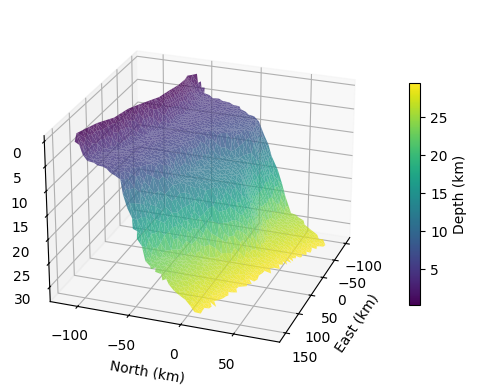

Fault(n_patches=2841, engine='tri')


In [2]:
# if our mesh is in the correct tri/ned format (see 'setup_data.ipynb'), we can load the fault model in one line:
fault=geodef.fault.Fault.load('fault/qiu+15_geo',format="ned")


# visualize fault in 3d
geodef.plot.fault3d(fault,
    color_by='depth',       # 'depth', 'area', 1-D array, or None
    cmap='viridis',
    show_edges=False,
    view=(25, 20),         # (elevation, azimuth) in degrees; None = matplotlib default
)
plt.show()
print(fault)

---
## 2. Load GNSS and InSAR data


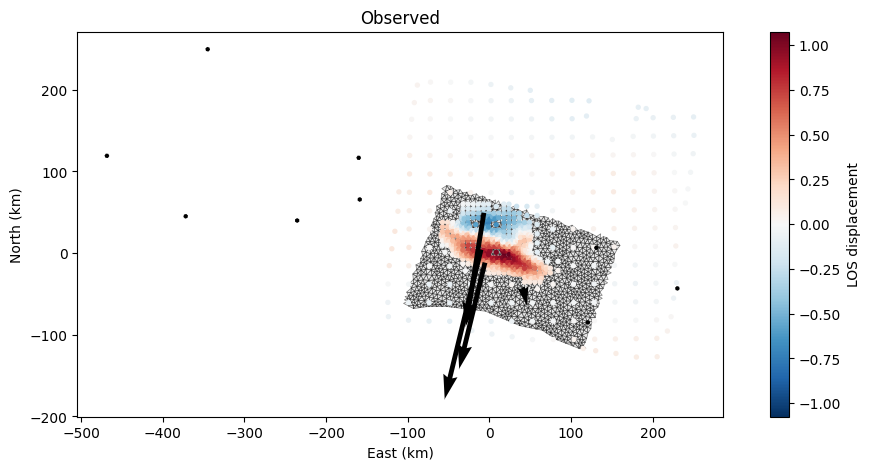

In [3]:
# load from file: expected columns are [lon, lat, hgt, uE, uN, uZ, sigE, sigN, sigZ]
gnss = geodef.data.GNSS.load('data/aria_offsets_for_geodef.dat')

# same approach for InSAR: expected columns [lat, lon, los, sigma, look_e, look_n, look_u]
insar = geodef.data.InSAR.load('data/t048_insar_for_geodef.dat')


# plot the data and fault together
fig,ax = plt.subplots(figsize=(12,5))
geodef.plot.map_view(fault,ax=ax)
geodef.plot.insar(insar,fault,ax=ax)
geodef.plot.vectors(gnss,fault,ax=ax,scale=100)
plt.show()

---

## 3. Run the inversion

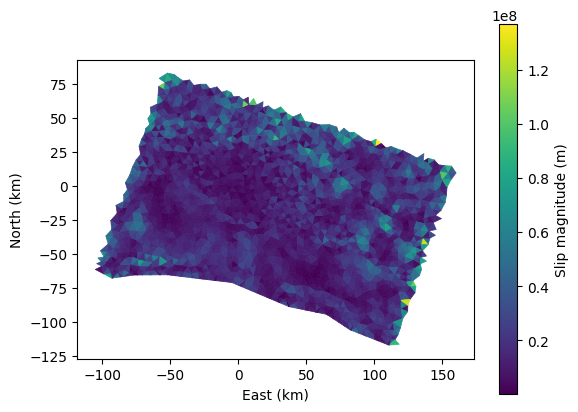

In [4]:
# if we just accept the defaults, running the inversion is very easy:
# this takes about 40 sec on my macbook the first time to compute the greens functions. 
# After the greens functions are cached, unsmoothed runs take < 1 sec, smoothed runs take about ~2sec.
result = geodef.invert.solve(fault,[gnss,insar])

# plot slip magnitude
geodef.plot.slip(fault, result.slip_vector, coords="geographic")
plt.show()

geodef does not add smoothing by default, so the above looks very bad! We should investigate the optimal smoothing parameter:

In [5]:
# From prior experimentation I know the rough range for the optimal value in this case is around 1e6 - 1e7.
# If you don't know this, you should start with a wider range, e.g. 1e-3 to 1e9, then zoom in.
# ABIC calculations require multiple matrix inversions so this process requires about 2 minutes (12 sec per test value)

# lc=geodef.abic_curve(fault,[gnss,insar],smoothing='laplacian',smoothing_range=(1e5,1e8),n=10)
# lc.plot()

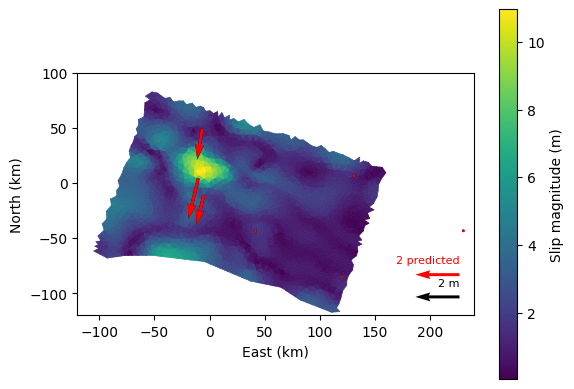

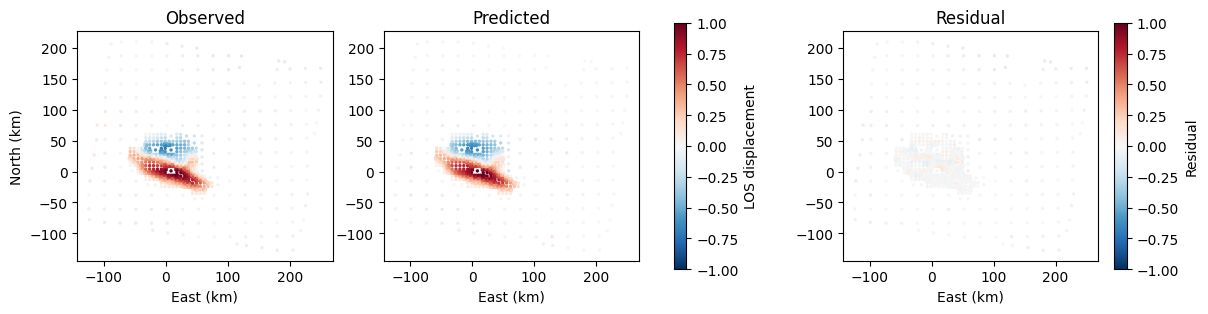

In [6]:
# now that we have our optimum smoothing strength, we can run the smoothed inversion:
result = geodef.invert.solve(fault,[gnss,insar],smoothing='laplacian',smoothing_strength=1e7)

# plot slip magnitude
ax=geodef.plot.slip(fault, result.slip_vector, coords="geographic")

# plot vectors
geodef.plot.vectors(gnss, fault,
    predicted=result.predicted[:gnss.n_obs],   # optional overlay
    scale=20,
    obs_color='black', pred_color='red',
    components='horizontal',    # 'horizontal', 'vertical', 'both'
    legend=True,
    scale_arrow=2, scale_arrow_label="2 m",
    scale_arrow_loc='lower right',
    ax=ax
)
plt.xlim([-120,240])
plt.ylim([-120,100])
plt.show()

# plot InSAR residuals
geodef.plot.insar(insar, fault,
    predicted=result.predicted[gnss.n_obs:],
    layout='obs_pred_res',    # 'obs', 'pred', 'residual', 'obs_pred_res'
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    scatter_kwargs={'s': 2},
)
plt.show()

-166.33268755367325
-166.3376903205432
-170.92580023783117


<Axes: xlabel='East (km)', ylabel='North (km)'>

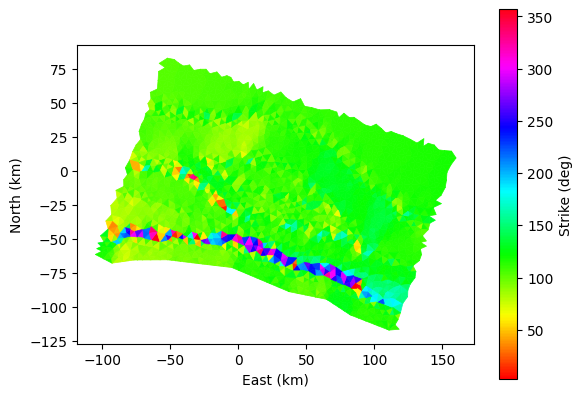

In [7]:
# Estimate a rough geographic slip azimuth from several large GNSS offsets.
print(180/np.pi*np.atan2(-0.44500000, -1.8300000))
print(180/np.pi*np.atan2(-0.31600000, -1.30000000))
print(180/np.pi*np.atan2(-0.22200000, -1.39000000))

geodef.plot.slip(fault, fault.strike, cmap='hsv', coords='geographic', colorbar_label='Strike (deg)')

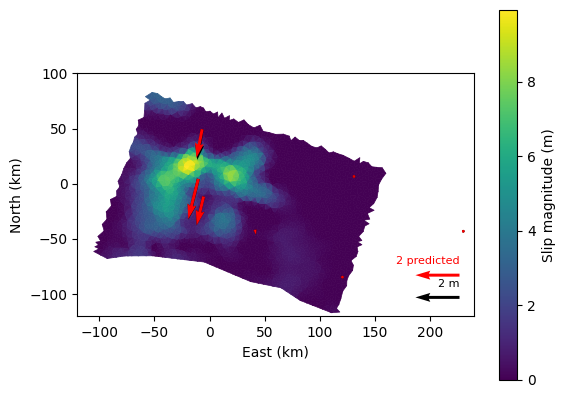

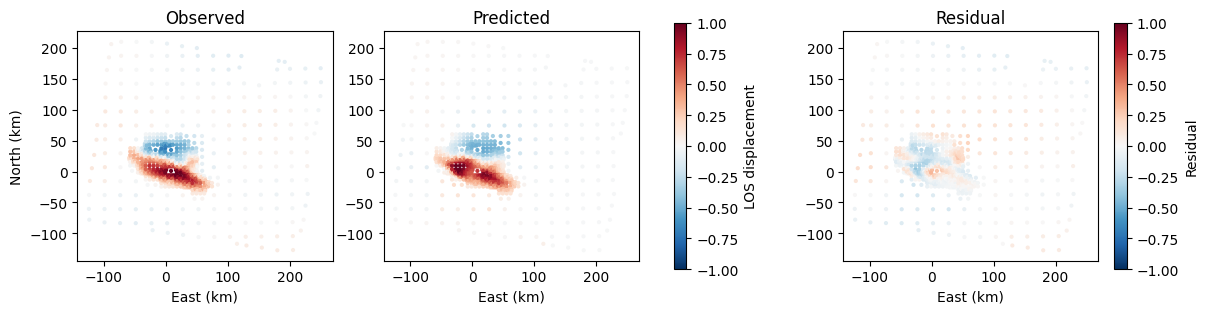

In [8]:
# Now fit a non-negative model with fixed geographic slip azimuth.
result = geodef.invert.solve(
    fault, [gnss, insar],
    smoothing='laplacian', smoothing_strength=1e8,
    components='azimuth', slip_azimuth=15.0,
    bounds=(0, None),
)

# plot slip amplitude
ax = geodef.plot.slip(fault, result.slip_vector, coords="geographic")

# plot vectors
geodef.plot.vectors(gnss, fault,
    predicted=result.predicted[:gnss.n_obs],   # optional overlay
    scale=20,
    obs_color='black', pred_color='red',
    components='horizontal',    # 'horizontal', 'vertical', 'both'
    legend=True,
    scale_arrow=2, scale_arrow_label="2 m",
    scale_arrow_loc='lower right',
    ax=ax
)
plt.xlim([-120,240])
plt.ylim([-120,100])
plt.show()

# plot InSAR residuals
geodef.plot.insar(insar, fault,
    predicted=result.predicted[gnss.n_obs:],
    layout='obs_pred_res',    # 'obs', 'pred', 'residual', 'obs_pred_res'
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    scatter_kwargs={'s': 4},
)
plt.show()